# Testing Data Cleaning

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns

orig_pums = pd.read_json("Downloads/2021-pums.json")
orig_pums.head()

,0,1,2,3,4
0,PWGTP,WRK,SEX,SOCP,ST
1,208,0,1,119111,06
2,88,1,2,119151,06
3,55,2,1,119111,06
4,87,1,2,113121,06


In [18]:
#Cleaning code for PUMS dataset

cleaned_pums = orig_pums.copy()

#Define 0th row as header
cleaned_pums.columns = cleaned_pums.iloc[0]
cleaned_pums = cleaned_pums.drop(cleaned_pums.index[0])
cleaned_pums = cleaned_pums.reset_index(drop=True)

#Keep the WRK, SEX, SOCP variables 
cleaned_pums = cleaned_pums[["WRK", "SEX", "SOCP"]]

#Replace 0 value in WRK with np.nan
cleaned_pums["WRK"] = cleaned_pums["WRK"].replace({0:np.nan})

<Axes: ylabel='0'>

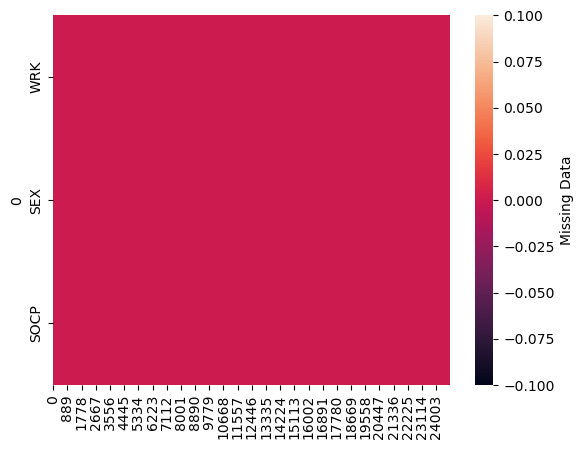

In [19]:
sns.heatmap(cleaned_pums.isna().transpose(),
           cbar_kws={"label":"Missing Data"})

In [20]:
cleaned_pums = cleaned_pums.dropna()

<Axes: ylabel='0'>

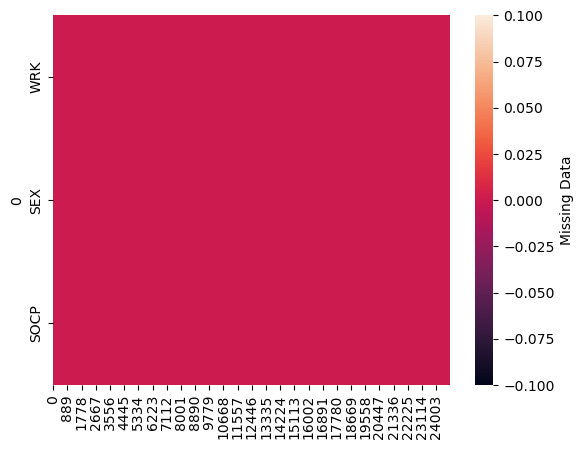

In [21]:
sns.heatmap(cleaned_pums.isna().transpose(),
           cbar_kws={"label":"Missing Data"})

In [23]:
#Read the excel file 
orig_wage_df = pd.read_excel("Downloads/oes_research_2021_sec_55-56.xlsx")
orig_wage_df.head()

,AREA,AREA_TITLE,NAICS,NAICS_TITLE,I_GROUP,OCC_CODE,OCC_TITLE,O_GROUP,TOT_EMP,EMP_PRSE,...,H_MEDIAN,H_PCT75,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY
0,1,Alabama,55,Management of Companies and Enterprises,sector,00-0000,All Occupations,total,21920,0,...,35.6,56.94,79.49,35470,47040,74050,118440,165330,NaN,NaN
1,1,Alabama,55,Management of Companies and Enterprises,sector,11-0000,Management Occupations,major,4820,4.1,...,61.13,92.03,#,61600,94020,127140,191420,#,NaN,NaN
2,1,Alabama,55,Management of Companies and Enterprises,sector,11-1021,General and Operations Managers,detailed,1600,7,...,60.5,#,#,60010,78520,125850,#,#,NaN,NaN
3,1,Alabama,55,Management of Companies and Enterprises,sector,11-2021,Marketing Managers,detailed,140,13.6,...,61.13,99.23,#,65240,98680,127140,206410,#,NaN,NaN
4,1,Alabama,55,Management of Companies and Enterprises,sector,11-2022,Sales Managers,detailed,140,14.7,...,49.56,77.94,#,59390,79010,103080,162110,#,NaN,NaN


In [24]:
#Making copy of Dataframe
cleaned_wage = orig_wage_df.copy()

#Replacing alphanumeric characters with NANs
cleaned_wage["H_MEAN"] = cleaned_wage["H_MEAN"].replace({"*": np.nan})
cleaned_wage["H_MEAN"] = cleaned_wage["H_MEAN"].replace({"#":np.nan})

#Filtering the dataframe to specific data elements.
cleaned_wage = cleaned_wage[["AREA_TITLE", "OCC_CODE", "OCC_TITLE", "H_MEAN"]]

#Filter to only value from California 
cleaned_wage = cleaned_wage[cleaned_wage["AREA_TITLE"] == "California"]

#Drop NA values
cleaned_wage = cleaned_wage.dropna()

/var/folders/hp/7w8yzdg13ng6crzbbv2st73w0000gn/T/ipykernel_66369/985582649.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cleaned_wage["H_MEAN"] = cleaned_wage["H_MEAN"].replace({"#":np.nan})


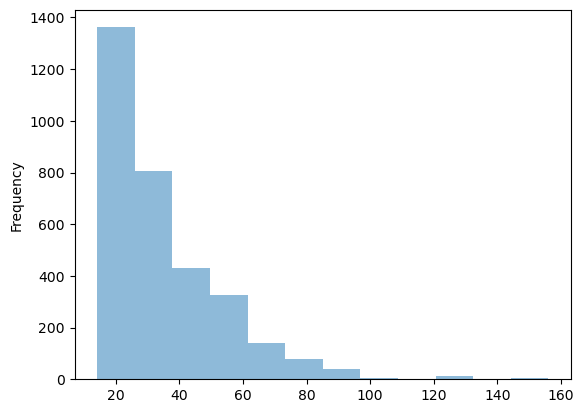

In [26]:
#Visually assess that the histogram values lie within an expected range
cleaned_wage["H_MEAN"].plot.hist(bins=12, alpha=0.5);

# Programmatic Asserts

In [27]:
print(cleaned_pums.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24873 entries, 0 to 24872
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   WRK     24873 non-null  object
 1   SEX     24873 non-null  object
 2   SOCP    24873 non-null  object
dtypes: object(3)
memory usage: 583.1+ KB
None


In [28]:
# For PUMS dataset check column data types are now accurate.
assert cleaned_pums.WRK.dtype == "object"
assert cleaned_pums.SEX.dtype == "object"
assert cleaned_pums.SOCP.dtype == "object"

In [29]:
# FOR oes dataset: check the column data is accurate 
assert cleaned_wage.H_MEAN.dtype == "float"

In [30]:
# For PUMS dataset: check programmatically that number of NA values is 0. 
assert cleaned_pums.isna().sum().sum() == 0

In [31]:
# For oes dataset: check programmatically that number of NA values is 0. 
assert cleaned_wage.isna().sum().sum() == 0